<a href="https://colab.research.google.com/github/sjsu-cs131-spring26/Misteam-Steam-Videogames/blob/main/Colab/Misteam_Project_Assign_5_CS131.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
!apt-get update -qq
!apt-get install -y openjdk-17-jdk-headless -qq
!pip install -q pyspark

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [37]:
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = f'{os.environ["JAVA_HOME"]}/bin:' + os.environ["PATH"]

In [38]:
!java -version
!echo $JAVA_HOME

openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
/usr/lib/jvm/java-17-openjdk-amd64


In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
DATASET_PATH = "/content/drive/Shareddrives/CS 131 Team Project/Datasets/steam_games_dataset_cleaned.tsv"

if (os.path.isfile(DATASET_PATH)):
  print("File exists");
else:
  print("File does not exist");

File exists


In [41]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ColabSparkSetup") \
    .master("local[*]") \
    .getOrCreate()

print(spark.version)

4.0.2


In [42]:
df = spark.read.csv(
    DATASET_PATH,
    header=True,
    inferSchema=True,
    sep="\t"
)

df.show(5)

+------+--------------------+------------+------------+-----+---------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------+-------+-----+-----+----------------+--------------------+------------+---------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------+--------------------+--------------------+--------------------+--------------------+----------+----------+--------+--------+--------------------+------------------------+-----------------------+-----------------------+----------------------+--------+--------+--------------------+-------------+-----------------+--------------+------------------+
| appid|                name|release_date|required_age|price|dlc_count|detailed_description|      about_the_game|   short_description|             reviews|        header_image|             website|         supp

In [43]:
df.columns

['appid',
 'name',
 'release_date',
 'required_age',
 'price',
 'dlc_count',
 'detailed_description',
 'about_the_game',
 'short_description',
 'reviews',
 'header_image',
 'website',
 'support_url',
 'support_email',
 'windows',
 'mac',
 'linux',
 'metacritic_score',
 'metacritic_url',
 'achievements',
 'recommendations',
 'notes',
 'supported_languages',
 'full_audio_languages',
 'packages',
 'developers',
 'publishers',
 'categories',
 'genres',
 'screenshots',
 'movies',
 'user_score',
 'score_rank',
 'positive',
 'negative',
 'estimated_owners',
 'average_playtime_forever',
 'average_playtime_2weeks',
 'median_playtime_forever',
 'median_playtime_2weeks',
 'discount',
 'peak_ccu',
 'tags',
 'pct_pos_total',
 'num_reviews_total',
 'pct_pos_recent',
 'num_reviews_recent']

In [44]:
df.select("discount").show(10)

+--------+
|discount|
+--------+
|       0|
|       0|
|       0|
|       0|
|      80|
|       0|
|       0|
|       0|
|      40|
|       0|
+--------+
only showing top 10 rows


In [45]:
df.printSchema()

df.select("user_score", "discount").show(20, truncate=False)

root
 |-- appid: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- release_date: date (nullable = true)
 |-- required_age: integer (nullable = true)
 |-- price: double (nullable = true)
 |-- dlc_count: integer (nullable = true)
 |-- detailed_description: string (nullable = true)
 |-- about_the_game: string (nullable = true)
 |-- short_description: string (nullable = true)
 |-- reviews: string (nullable = true)
 |-- header_image: string (nullable = true)
 |-- website: string (nullable = true)
 |-- support_url: string (nullable = true)
 |-- support_email: string (nullable = true)
 |-- windows: boolean (nullable = true)
 |-- mac: boolean (nullable = true)
 |-- linux: boolean (nullable = true)
 |-- metacritic_score: integer (nullable = true)
 |-- metacritic_url: string (nullable = true)
 |-- achievements: integer (nullable = true)
 |-- recommendations: integer (nullable = true)
 |-- notes: string (nullable = true)
 |-- supported_languages: string (nullable = true)
 |-- ful

In [46]:
from pyspark.sql.functions import col, regexp_replace

df2 = df.withColumn(
    "user_score_clean",
    col("user_score").cast("double")
).withColumn(
    "discount_clean",
    regexp_replace(col("discount").cast("string"), "%", "").cast("double")
)

df2.select("user_score", "user_score_clean", "discount", "discount_clean").show(20, truncate=False)

+----------+----------------+--------+--------------+
|user_score|user_score_clean|discount|discount_clean|
+----------+----------------+--------+--------------+
|0         |0.0             |0       |0.0           |
|0         |0.0             |0       |0.0           |
|0         |0.0             |0       |0.0           |
|0         |0.0             |0       |0.0           |
|0         |0.0             |80      |80.0          |
|0         |0.0             |0       |0.0           |
|0         |0.0             |0       |0.0           |
|0         |0.0             |0       |0.0           |
|0         |0.0             |40      |40.0          |
|0         |0.0             |0       |0.0           |
|0         |0.0             |0       |0.0           |
|0         |0.0             |0       |0.0           |
|0         |0.0             |0       |0.0           |
|0         |0.0             |0       |0.0           |
|0         |0.0             |0       |0.0           |
|0         |0.0             

In [47]:
df2 = df2.filter(
    col("user_score_clean").isNotNull() &
    col("discount_clean").isNotNull() &
    (col("user_score_clean") >= 0) &
    (col("user_score_clean") <= 100) &
    (col("discount_clean") >= 0) &
    (col("discount_clean") <= 100)
)

In [48]:
from pyspark.sql.functions import when

df2 = df2.withColumn(
    "user_score_bucket",
    when(col("user_score_clean") < 20, "0-20")
    .when(col("user_score_clean") < 40, "20-40")
    .when(col("user_score_clean") < 60, "40-60")
    .when(col("user_score_clean") < 80, "60-80")
    .otherwise("80-100")
).withColumn(
    "discount_bucket",
    when(col("discount_clean") < 10, "0-10")
    .when(col("discount_clean") < 20, "10-20")
    .when(col("discount_clean") < 30, "20-30")
    .when(col("discount_clean") < 40, "30-40")
    .when(col("discount_clean") < 50, "40-50")
    .when(col("discount_clean") < 60, "50-60")
    .when(col("discount_clean") < 70, "60-70")
    .when(col("discount_clean") < 80, "70-80")
    .when(col("discount_clean") < 90, "80-90")
    .otherwise("90-100")
)

In [49]:
bucket_counts = df2.groupBy("user_score_bucket", "discount_bucket").count()
bucket_counts.orderBy("user_score_bucket", "discount_bucket").show(100, truncate=False)

+-----------------+---------------+-----+
|user_score_bucket|discount_bucket|count|
+-----------------+---------------+-----+
|0-20             |0-10           |82133|
|0-20             |10-20          |305  |
|0-20             |20-30          |845  |
|0-20             |30-40          |731  |
|0-20             |40-50          |560  |
|0-20             |50-60          |1742 |
|0-20             |60-70          |614  |
|0-20             |70-80          |1014 |
|0-20             |80-90          |1003 |
|0-20             |90-100         |632  |
|20-40            |0-10           |1    |
|40-60            |0-10           |7    |
|60-80            |0-10           |10   |
|60-80            |50-60          |1    |
|60-80            |70-80          |2    |
|80-100           |0-10           |13   |
|80-100           |40-50          |1    |
|80-100           |50-60          |2    |
|80-100           |60-70          |1    |
|80-100           |70-80          |1    |
+-----------------+---------------

In [50]:
pivot_table = df2.groupBy("user_score_bucket") \
    .pivot("discount_bucket", ["0-10","10-20","20-30","30-40","40-50","50-60","60-70","70-80","80-90","90-100"]) \
    .count() \
    .fillna(0)

pivot_table.show(truncate=False)

+-----------------+-----+-----+-----+-----+-----+-----+-----+-----+-----+------+
|user_score_bucket|0-10 |10-20|20-30|30-40|40-50|50-60|60-70|70-80|80-90|90-100|
+-----------------+-----+-----+-----+-----+-----+-----+-----+-----+-----+------+
|20-40            |1    |0    |0    |0    |0    |0    |0    |0    |0    |0     |
|0-20             |82133|305  |845  |731  |560  |1742 |614  |1014 |1003 |632   |
|60-80            |10   |0    |0    |0    |0    |1    |0    |2    |0    |0     |
|80-100           |13   |0    |0    |0    |1    |2    |1    |1    |0    |0     |
|40-60            |7    |0    |0    |0    |0    |0    |0    |0    |0    |0     |
+-----------------+-----+-----+-----+-----+-----+-----+-----+-----+-----+------+



In [51]:
from pyspark.sql.functions import lit

cols = ["0-10","10-20","20-30","30-40","40-50","50-60","60-70","70-80","80-90","90-100"]

pivot_with_total = pivot_table
for c in cols:
    pivot_with_total = pivot_with_total.withColumn(c, col(c).cast("double"))

total_expr = None
for c in cols:
    total_expr = col(c) if total_expr is None else total_expr + col(c)

pivot_with_total = pivot_with_total.withColumn("row_total", total_expr)

ratio_table = pivot_with_total.select(
    "user_score_bucket",
    *[
        (col(c) / col("row_total")).alias(c + "_ratio")
        for c in cols
    ]
)

ratio_table.show(truncate=False)

+-----------------+------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+-------------------+--------------------+--------------------+
|user_score_bucket|0-10_ratio        |10-20_ratio         |20-30_ratio         |30-40_ratio         |40-50_ratio         |50-60_ratio        |60-70_ratio         |70-80_ratio        |80-90_ratio         |90-100_ratio        |
+-----------------+------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+-------------------+--------------------+--------------------+
|20-40            |1.0               |0.0                 |0.0                 |0.0                 |0.0                 |0.0                |0.0                 |0.0                |0.0                 |0.0                 |
|0-20             |0.9168778396722446|0.003404815860860246|0.009433014434186584|0.00816039473537

In [52]:
from pyspark.sql.functions import split, explode, count, desc, regexp_replace, trim, sum as _sum

#Split the genres and explode into individual rows
genres_df = df.withColumn("genre_clean", regexp_replace(col("genres"), r"[\[\]']", "")) \
              .withColumn("genre_array", split(col("genre_clean"), ","))

# Explode and count
genre_popularity = genres_df.withColumn("single_genre", explode(col("genre_array"))) \
    .withColumn("single_genre", trim(col("single_genre"))) \
    .groupBy("single_genre") \
    .agg(count("*").alias("game_count"), _sum("positive").alias("total_positives")) \
    .orderBy(desc("game_count"))

genre_popularity.show(20)

+--------------------+----------+---------------+
|        single_genre|game_count|total_positives|
+--------------------+----------+---------------+
|               Indie|     63189|       47782278|
|              Casual|     38699|       15547522|
|              Action|     36842|       76332613|
|           Adventure|     35452|       46954872|
|          Simulation|     18570|       23727444|
|            Strategy|     17366|       19349263|
|                 RPG|     16342|       30745017|
|        Early Access|      9113|        6664495|
|        Free To Play|      8867|       22702231|
|              Sports|      3939|        3468376|
|              Racing|      3301|        2835812|
|Massively Multipl...|      2123|       10397202|
|           Utilities|       856|        1103275|
|Design & Illustra...|       494|        1050381|
|             Violent|       429|          46104|
|Animation & Modeling|       394|        1022972|
|           Education|       390|          68122|


+---------------+-----------+---------+---------+-------------+
|platform_suite |total_games|total_pos|total_neg|success_ratio|
+---------------+-----------+---------+---------+-------------+
|Win            |68931      |63900055 |12791538 |0.8332       |
|Win + Mac + Lin|9377       |24881705 |2803150  |0.8987       |
|Win + Mac      |8039       |13918387 |1644323  |0.8943       |
|Win + Lin      |3241       |11104964 |1562855  |0.8766       |
|Mac            |21         |227      |142      |0.6152       |
|Lin            |8          |84       |56       |0.6          |
|Mac + Lin      |1          |116      |21       |0.8467       |
+---------------+-----------+---------+---------+-------------+



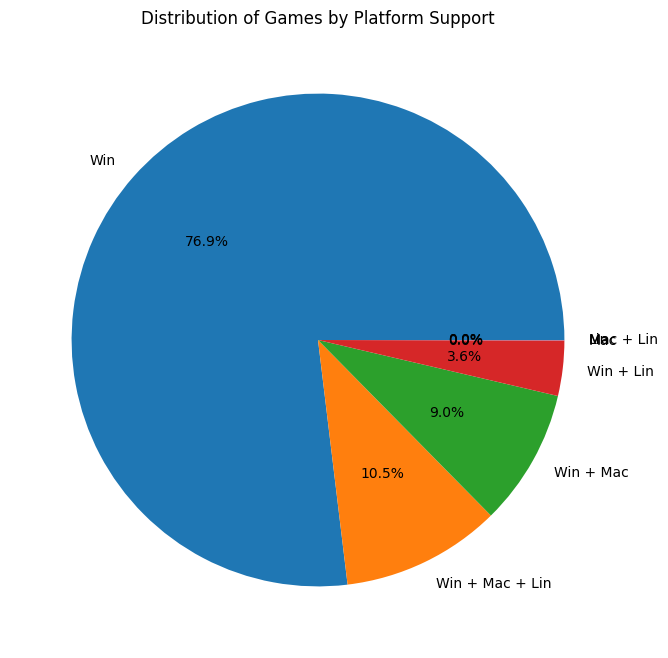

In [60]:
from pyspark.sql.functions import concat_ws, lit, round, avg
import matplotlib.pyplot as plt

df_platforms = df.withColumn("platform_suite",
    concat_ws(" + ",
        when(col("windows") == "true", lit("Win")),
        when(col("mac") == "true", lit("Mac")),
        when(col("linux") == "true", lit("Lin"))
    )
)

platform_success = df_platforms.groupBy("platform_suite") \
    .agg(
        count("*").alias("total_games"),
        _sum("positive").alias("total_pos"),
        _sum("negative").alias("total_neg"),
        ) \
    .withColumn("success_ratio", round(col("total_pos") / (col("total_pos") + col("total_neg")), 4)) \
    .orderBy(desc("total_games"))

platform_success.show(truncate=False)


pdf_platform = platform_success.toPandas()

plt.figure(figsize=(8, 8))
plt.pie(pdf_platform["total_games"], labels=pdf_platform['platform_suite'], autopct='%1.1f%%')
plt.title('Distribution of Games by Platform Support')
plt.show()

In [54]:
# Create Metacritic buckets
df_meta = df.withColumn("meta_score", col("metacritic_score").cast("int")).filter(col("meta_score") > 0)
df_meta = df_meta.withColumn("meta_bucket",
    when(col("meta_score") >= 80, "80-100 (High)")
    .when(col("meta_score") >= 60, "60-79 (Mid)")
    .otherwise("0-59 (Low)"))

meta_vs_user = df_meta.groupBy("meta_bucket") \
    .agg(
        _sum("positive").alias("total_pos"),
        _sum("negative").alias("total_neg")
    ) \
    .withColumn("user_success_ratio", round(col("total_pos") / (col("total_pos") + col("total_neg")), 4)) \
    .orderBy("meta_bucket")

meta_vs_user.show()

+-------------+---------+---------+------------------+
|  meta_bucket|total_pos|total_neg|user_success_ratio|
+-------------+---------+---------+------------------+
|   0-59 (Low)|   445070|   145538|            0.7536|
|  60-79 (Mid)| 15628230|  2662060|            0.8545|
|80-100 (High)| 41168381|  4752489|            0.8965|
+-------------+---------+---------+------------------+

